# Содержание

* [1-Обзор данных](#1)
* [2-Предобработка данных](#2)
  * [2.1-Изменение типов данных](#2.1)
  * [2.2-Категоризация данных](#2.2)
  * [2.3-Обработка явных дубликатов](#2.3)
  * [2.4-Обработка неявных дубликатов](#2.4)
  * [2.5-Обработка аномальных значений](#2.5)
* [3-Исследовательский анализ данных](#3)
* [4-Объединение данных](#4)
* [5-Подсчёт выручки](#5)
* [6-Проверка гипотез](#6)
  * [6.1-Гипотеза: пользователи с подпиской тратят больше времени на поездки](#6.1)
  * [6.2-Гипотеза: среднее расстояние за одну поездку у пользователей с подпиской не превышает 3130](#6.2)
  * [6.3-Гипотеза: выручка от пользователей с подпиской по месяцам будет выше, чем выручка от пользователей без подписки](#6.3)
  * [6.4-Гипотеза: количество обращений в техподдержку значительно снизилось после обновления серверов](#6.4)
* [7-Общий вывод](#7)

# Статистический анализ данных

**Цель исследования** — проанализировать данные и проверить 3 гипотезы, которые могут помочь бизнесу вырасти:

1. Пользователи с подпиской тратят больше времени на поездки

2. Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130

3. Помесячная выручка от пользователей с подпиской по месяцам будет выше, чем выручка от пользователей без подписки.

А также предположим способ проверки гипотезы:

* Kоличество обращений в техподдержку значительно снизилось после обновления серверов, с которыми взаимодействует мобильное приложение.

**Описание данных**

В этом исследовании мы используем данные сервиса аренды самокатов "GoFast": информацию о пользователях, их поездках и подписках.

Сервисом можно пользоваться:

Без подписки


   * Абонентская плата отсутствует;
   * Стоимость одной минуты поездки — 8 рублей;
   * Стоимость старта (начала поездки) — 50 рублей;
    
С подпиской Ultra


   * Абонентская плата — 199 рублей в месяц;
   * Стоимость одной минуты поездки — 6 рублей;
   * Стоимость старта — бесплатно.
   
   
Мы получим данные:


О пользователях из файла `users_go.csv`:


* `user_id` — уникальный идентификатор пользователя;
* `name` — имя пользователя;
* `age` — возраст;
* `city` — город;
* `subscription_type` — тип подписки (free, ultra);


О поездках из файла `rides_go.csv`:


* `user_id` — уникальный идентификатор пользователя;
* `distance` — расстояние, которое пользователь проехал в текущей сессии (в метрах);
* `duration` — продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»;
* `date` — дата совершения поездки;


О подписках из файла `subscriptions_go.csv`:


* `subscription_type` — тип подписки;
* `minute_price` — стоимость одной минуты поездки по данной подписке;
* `start_ride_price` — стоимость начала поездки;
* `subscription_fee` — стоимость ежемесячного платежа.


**Ход исследования**

Исследование пройдёт в три этапа:

1. Обзор данных.

Ознакомимся с содержанием, структурой и характеристиками данных. 

2. Предобработка данных.

Проведём тщательную проверку на наличие ошибок и оценим их влияние.

3. Исследовательский анализ данных.

Проанализируем обработанные данные и проверим гипотезы.

<a name="1"></a>
## Обзор данных

Считаем CSV-файлы с данными и сохраним их в датафреймы:

In [1]:
# импортируем все необходимые библиотеки,чтобы сразу видеть, какие модули используются в проекте
# выгрузим pandas, numpy, matplotlib, scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

In [2]:
# сохраним в переменную ссылку на первый датафрейм - users_go
users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')

In [3]:
# сохраним в переменную сылку на второй датафрейм - rides_go
rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')

In [4]:
# сохраним в переменную ссылку на третий датафрейм - subscriptions_go
subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

Выведем первые строки каждого набора данных:

In [5]:
# выведем первые 30 строк датафрейма с помощью head()
users_go.head(30)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


In [6]:
# выведем первые 30 строк датафрейма с помощью head()
rides_go.head(30)

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


In [7]:
# выведем первые 30 строк датафрейма с помощью head()
subscriptions_go.head(30)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


На первый взгляд в датафреймах отсутствуют подозрительные данные или аномалии.

Изучим общую информацию о каждом датафрейме:

In [8]:
# ознакомимся с общей информацией с помощью info()
users_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


В данных отсутствуют пропуски, корректны названия столбцов и типы данных.

In [9]:
# ознакомимся с общей информацией с помощью info()
rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


Столбцы датафреймов не имеют пропущенных значений. Сомнения вызывает тип данных **object** в столбце `date` с датой совершения поездки. В дальнейшем значения в столбце можно привести к типу **datetime** для применения методов к датам в ходе исследовательского анализа.

In [10]:
# ознакомимся с общей информацией с помощью info()
subscriptions_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


В датафрейме с информацией о подписке также отсутствуют пропуски в столбцах. 

**Выводы**:

* В датафрейме о пользователях `users_go` **5** столбцов и **1565** строк, в датафрейме о поездках `rides_go` **4** столбца и **18 068** строк, в `subscriptions_go` — **4** колонки и **2** строки.
* На первый взгляд, в таблицах отсутствуют подозрительные данные. Корректно обозначены названия столбцов, отсутствуют пропуски. Возможно, в дальнейшем возникнет необходимость перевести значения столбца `date` из **строкового** типа данных к типу **datetime** для применения методов к датам.

<a name="2"></a>
## Предобработка данных 

<a name="2.1"></a>
### Изменение типов данных

Приведём столбец `date` в таблице `rides_go` к типу даты pandas:

In [11]:
# преобразуем строку в datetime с помощью to_datetime()
rides_go['date'] = pd.to_datetime(
    rides_go['date'],
    format='%Y-%m-%d'
)

# проверим результат
rides_go['date'].dtype

dtype('<M8[ns]')

<a name="2.2"></a>
### Категоризация данных

Создадим в датафрейме `rides_go` новый столбец с номером месяца на основе столбца `date`

In [12]:
# выделим номер месяца из даты поездки
rides_go['month_number'] = rides_go['date'].dt.month

# проверим результат
rides_go.head()

,user_id,distance,duration,date,month_number
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Проверим, за какой период содержит данные столбец `date`: 

In [13]:
rides_go['date'].dt.year.unique()

array([2021])

В столбце представлены данные только за один год  — **2021**.

Округлим до следующего целого числа продолжительность каждой поездки в каждой строке датафрейма `rides_go`:

In [14]:
# округлим каждое значение из столбца с помощью "потолка"
rides_go['duration'] = np.ceil(rides_go['duration'])

# проверим рещультат
rides_go.head()

,user_id,distance,duration,date,month_number
0,1,4409.919140,26.0,2021-01-01,1
1,1,2617.592153,16.0,2021-01-18,1
2,1,754.159807,7.0,2021-04-20,4
3,1,2694.783254,19.0,2021-08-11,8
4,1,4028.687306,27.0,2021-08-28,8


Создадим в датафрейме `users_go` столбец `age_category` с категориями на основании следующих диапазонов:

* 12-18 — `от 12 до 18 лет`
* 18-25 — `от 18 до 25 лет`
* 25-30 — `от 25 до 30 лет`
* 30-35 — `от 30 до 35 лет`
* 35-43 — `от 35 до 43 лет`

Например, пользователю в возрасте 25 лет присвоим категорию `от 25 до 30 лет`. Напишем функцию `categorize_age` и используем метод `apply()`:

In [15]:
# напишем функцию для разделения данных с параметром - столбец с возрастом пользователя 
# в теле функции используем условные конструкции для разделения данных
def categorize_age(age):
    
    if 12 <= age <= 18:
        return 'от 12 до 18 лет'
    elif 18 <= age <= 25:
        return 'от 18 до 25 лет'
    elif 25 <= age <= 30:
        return 'от 25 до 30 лет'
    elif 30 <= age <= 35:
        return 'от 30 до 35 лет'
    elif 35 <= age <= 43:
        return 'от 35 до 43 лет'

# протестируем функцию
# categorize_age(40)

In [16]:
# применим функцию методом apply() и сохраним результат в столбец age_category
users_go['age_category'] = users_go['age'].apply(categorize_age)

# проверим результат
users_go.head()

,user_id,name,age,city,subscription_type,age_category
0,1,Кира,22,Тюмень,ultra,от 18 до 25 лет
1,2,Станислав,31,Омск,ultra,от 30 до 35 лет
2,3,Алексей,20,Москва,ultra,от 18 до 25 лет
3,4,Константин,26,Ростов-на-Дону,ultra,от 25 до 30 лет
4,5,Адель,28,Омск,ultra,от 25 до 30 лет


<a name="2.3"></a>
### Обработка явных дубликатов

Проверим таблицы на наличие явных дубликатов:

In [17]:
# используем методы duplicated() и sum() для подсчёта явных дублей 
users_go.duplicated().sum()

31

In [18]:
# используем методы duplicated() и sum() для подсчёта явных дублей 
rides_go.duplicated().sum()

0

In [19]:
# используем методы duplicated() и sum() для подсчёта явных дублей 
subscriptions_go.duplicated().sum()

0

Явные дубликаты обнаружены только в одном датафрейме — `users_go`. Очистим от них таблицу:

In [20]:
# удалим явные дубликаты и заменим исходные индексы на новые
users_go = users_go.drop_duplicates().reset_index(drop=True)

# проверим результат
users_go.duplicated().sum()

0

<a name="2.4"></a>
### Обработка неявных дубликатов

* Проверим столбцы датафрейма `users_go` на наличие неявных дубликатов:

In [21]:
# выведем список уникальных значений с помощью unique()
sorted(users_go['user_id'].unique())

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185

Значения в столбце выглядят упорядоченно, неявные дубликаты отсутствуют.

In [22]:
# выведем список уникальных значений с помощью unique()
sorted(users_go['age'].unique())

[12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 43]

Возраст пользователей варьируется от **12** до **43** лет. В столбце отсутствуют дубли.

In [23]:
# выведем список уникальных значений с помощью unique()
sorted(users_go['name'].unique())

['Агата',
 'Аделина',
 'Адель',
 'Айдар',
 'Александр',
 'Александра',
 'Алексей',
 'Алина',
 'Алиса',
 'Алия',
 'Алла',
 'Альберт',
 'Альбина',
 'Алёна',
 'Амалия',
 'Амина',
 'Амир',
 'Анастасия',
 'Анатолий',
 'Ангелина',
 'Андрей',
 'Анжелика',
 'Анна',
 'Антон',
 'Антонина',
 'Ариана',
 'Арина',
 'Арсен',
 'Арсений',
 'Артемий',
 'Артур',
 'Артём',
 'Богдан',
 'Борис',
 'Вадим',
 'Валентина',
 'Валерий',
 'Валерия',
 'Варвара',
 'Василий',
 'Василина',
 'Василиса',
 'Вера',
 'Вероника',
 'Виктор',
 'Виктория',
 'Виолетта',
 'Виталий',
 'Виталина',
 'Влад',
 'Влада',
 'Владимир',
 'Владислав',
 'Владислава',
 'Всеволод',
 'Вячеслав',
 'Галина',
 'Георгий',
 'Герман',
 'Глеб',
 'Гордей',
 'Григорий',
 'Давид',
 'Дамир',
 'Даниил',
 'Данил',
 'Данила',
 'Даниэль',
 'Дарина',
 'Дарья',
 'Демид',
 'Денис',
 'Диана',
 'Дмитрий',
 'Ева',
 'Евгений',
 'Евгения',
 'Егор',
 'Екатерина',
 'Елена',
 'Елизавета',
 'Елисей',
 'Есения',
 'Жанна',
 'Зарина',
 'Захар',
 'Злата',
 'Иван',
 'Игнат',

Имя "Наташа" является уменьшительно-ласкательной формой имён "Наталия" и "Наталья". Мы не будем считать его неявным дубликатом, так как пользователь мог сознательно выбрать именно это имя при регистрации в сервисе. Кроме того, в редких случаях "Наташа" может использоваться как самостоятельное полное имя.

In [24]:
# выведем список уникальных значений с помощью unique()
sorted(users_go['city'].unique())

['Екатеринбург',
 'Краснодар',
 'Москва',
 'Омск',
 'Пятигорск',
 'Ростов-на-Дону',
 'Сочи',
 'Тюмень']

In [25]:
# выведем список уникальных значений с помощью unique()
sorted(users_go['subscription_type'].unique())

['free', 'ultra']

Неявные дубликаты отсутствуют в столбцах с наименованиями городов и типом подписки.

* Проверим столбец `user_id` в датафрейме `rides_go` на наличие неявных дубликатов:

In [26]:
# выведем список уникальных значений с помощью unique()
sorted(rides_go['user_id'].unique())

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185

Значения выглядят упорядоченно, неявные дубли отсутствуют.

* Проверим столбцы датафрейма `subscriptions_go` на наличие неявных дубликатов:

In [27]:
# выведем список уникальных значений с помощью unique()
sorted(subscriptions_go['subscription_type'].unique())

['free', 'ultra']

In [28]:
# выведем список уникальных значений с помощью unique()
sorted(subscriptions_go['minute_price'].unique())

[6, 8]

In [29]:
# выведем список уникальных значений с помощью unique()
sorted(subscriptions_go['start_ride_price'].unique())

[0, 50]

In [30]:
# выведем список уникальных значений с помощью unique()
sorted(subscriptions_go['subscription_fee'].unique())

[0, 199]

Неявные дубли отсутствуют во всех столбцах датафрейма с категориальными значениями.

<a name="2.5"></a>
### Обработка аномальных значений

Посмотрим, как распределены значения в датафрейме `rides_go` в столбцах с непрерывными количественными переменными — `distance` и `duration`. 

Построим гистограмму по столбцу `distance`:

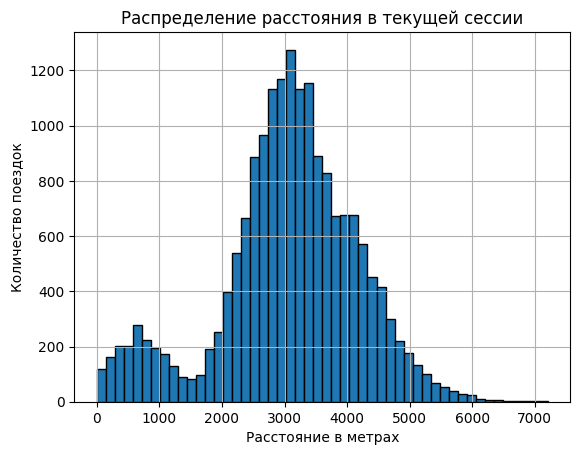

In [31]:
# построим гистограмму по столбцу distance и установим количество корзин - 50
rides_go['distance'].hist(edgecolor='black', bins=50)

# обозначим название графика и осей x и y
plt.title('Распределение расстояния в текущей сессии')
plt.ylabel('Количество поездок')
plt.xlabel('Расстояние в метрах')

# выведем график на экран
plt.show()

* График демонстрирует ассиметричное бимодальное распределение с двумя пиками: менее выраженный в районе 600 метров и более высокий — 3 000 метров. 


* В этом случае лучше описать центр данных с помощью медианы, поскольку она устойчива к экстремальным значениям и в столбце находятся непрерывные величины.


* Заметна концентрация значений у отметки 0. Это могут быть минимальные значения, близкие к нулю. Такие значения могли возникнуть из-за ошибок сбора данных или в ситуации, если пользователь арендовал самокат на очень короткое расстояние, например, чтобы его протестировать.

Ознакомимся с числовым описанием данных:

In [32]:
# выведем числовое описание данных с помощью describe()
rides_go['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

* Высокое стандартное отклонение — **1 116** говорит о наличии выбросов или аномальных значений в данных.
* Минимальное значение —  **0.855683** действительно выглядит подозрительно и, скорее всего, является аномалией.

Построим диаграмму размаха для проверки данных на наличие выбросов:

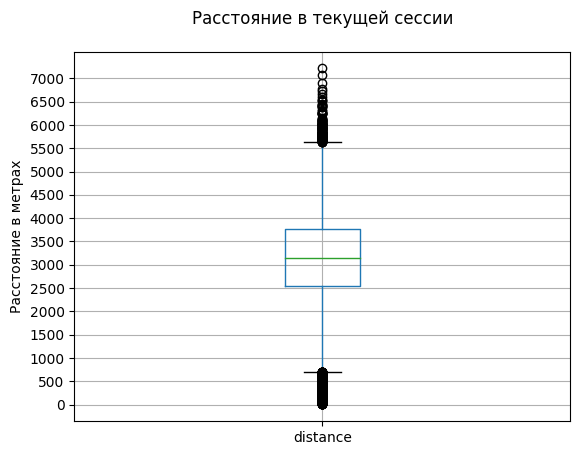

In [33]:
# построим диаграмму размаха с помощью boxplot()
rides_go.boxplot(column='distance')

# обозначим название диаграммы
# поставим метки на оси y с шагом - 500
# назовём ось y
plt.title('Расстояние в текущей сессии', pad=20)
plt.yticks(range(0, 7211, 500))
plt.ylabel('Расстояние в метрах')

# выведем график на экран
plt.show()

* На диаграмме видны выбросы от отметки **5 500** до **7 211** метров. 

* Также можно заметить выбросы у нижнего уса, приблизительно от **0** до **700** метров.

Эти значения можно считать реалистичными, так как на электросамокате действительно можно проехать такое расстояние за одну сессию. Однако самокат редко арендуют для очень длинных или, наоборот, очень коротких поездок.

Рассчитаем верхнюю и нижнюю границы нормального размаха:

In [34]:
# напишем функцию для расчета межквартильного размаха
# рассчитаем верхнюю и нижнюю границы нормального размаха
def emission_limit(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    result= print(
        f"Верхняя граница выбросов = {upper_limit:.2f}\nНижняя граница выбросов = {lower_limit:.2f}")
    return result

# вызовем функцию и выведем результаты на экран
emission_limit(rides_go, 'distance')

Верхняя граница выбросов = 5625.72
Нижняя граница выбросов = 693.73


Аномальные значения могут смещать среднее вверх. Однако в этом случае нецелесообразно удалять данные, так как пользователи оплатили старт поездки и удаление повлияет на выручку.

Построим гистограмму по столбцу `duration`:

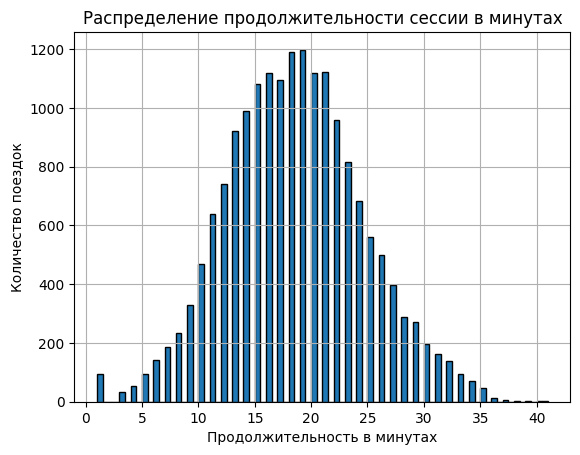

In [35]:
# построим гистограмму по столбцу duration и установим количество корзин - 80
rides_go['duration'].hist(edgecolor='black', bins=80)

# обозначим название графику
# назовём оси x и y
plt.title('Распределение продолжительности сессии в минутах')
plt.xlabel('Продолжительность в минутах')
plt.ylabel('Количество поездок')

# выведем на экран
plt.show()

* Значения распределены достаточно равномерно, но можно заметить узкий пик у отметки **1**. 

Ознакомимся с числовым описанием данных:

In [36]:
# выведем числовое описание с помощью describe()
rides_go['duration'].describe()

count    18068.000000
mean        18.303520
std          6.094928
min          1.000000
25%         14.000000
50%         18.000000
75%         22.000000
max         41.000000
Name: duration, dtype: float64

* Высокое стандартное отклонение — **6**. Скорее всего, в данных присутствуют выбросы или аномальные значения.


* Сомнения вызывают минимальное и максимальное значения — **1** и **41** минута. Короткая сессия, длительностью всего несколько секунд, могла возникнуть по ошибке, например, если пользователь арендовал самокат, но не использовал его. Максимальное значение выглядит реалистично, однако пользователи редко арендуют самокат на такое длительное время.

Построим диаграмму размаха:

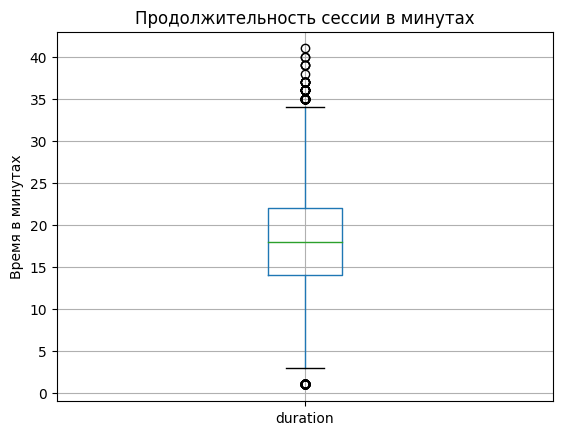

In [37]:
# построим "ящик с усами" с помощью boxplot()
rides_go.boxplot(column='duration')

# обозначим название диаграммы
# подпишем ось y
plt.title('Продолжительность сессии в минутах')
plt.ylabel('Время в минутах')

# выведем на экран
plt.show()

* На диаграмме видны выбросы у верхнего уса, приблизительно после отметки в **34** минуты, а также у нижнего уса — около **2** минут.

Рассчитаем межквартильный размах с помощью функции:

In [38]:
# вызовем функцию для расчёта межквартильного размаха
emission_limit(rides_go, 'duration')

Верхняя граница выбросов = 34.00
Нижняя граница выбросов = 2.00


Удаление данных аналогично может исказить результаты расчёта выручки, так как пользователи оплачивают стоимость каждой минуты поездки.

**Выводы**:

На этапе предобработки были обнаружены следующие проблемы в данных:

* Некорректный тип данных;
* Явные дубликаты;
* Аномальные значения в столбцах с непрерывными количественными переменными.

После устранения проблем перейдём к исследовательскому анализу данных.

<a name="3"></a>
## Исследовательский анализ данных

Опишем и визуализируем общую информацию о пользователях и поездках:

* Частоту встречаемости городов
* Соотношение пользователей с подпиской и без подписки
* Возраст пользователей
* Расстояние, которое пользователь преодолел за одну поездку
* Продолжительность поездок

Посмотрим, насколько часто встречается каждый город в датафрейме `users_go`. Так как столбец `city` содержит категориальные переменные, визуализируем информацию с помощью столбчатой диаграммы:

In [39]:
# подсчитаем, сколько раз каждый город встречается в датафрейме
city_counts = users_go['city'].value_counts()  

# выведем результат на экран
city_counts

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

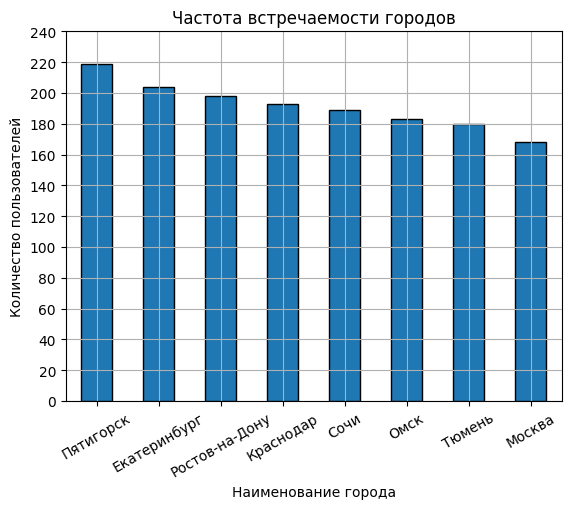

In [40]:
# построим столбчатую диаграмму методом plot()
city_counts.plot(kind='bar', edgecolor='black')

# обозначим заголовок диаграммы
# назовём оси x и y
# проставим метки на оси y с шагом 20
# повернём подписи
# добавим сетку
plt.title('Частота встречаемости городов')
plt.xlabel('Наименование города')
plt.ylabel('Количество пользователей')
plt.yticks(range(0, 250, 20))
plt.xticks(rotation=30)
plt.grid(True)

# выведем результат на экран
plt.show()

* На диаграмме можно увидеть небольшую разницу в количестве пользователей в разных городах. 
* Самое большое количество пользователей сервиса для аренды самокатов находится в Пятигорске — **219** человек.
* Самое маленькое количество пользователей находится в столице — **168** человек.

Проверим соотношение пользователей с подпиской и без подписки, визуализируем конверсию с помощью круговой диаграммы:

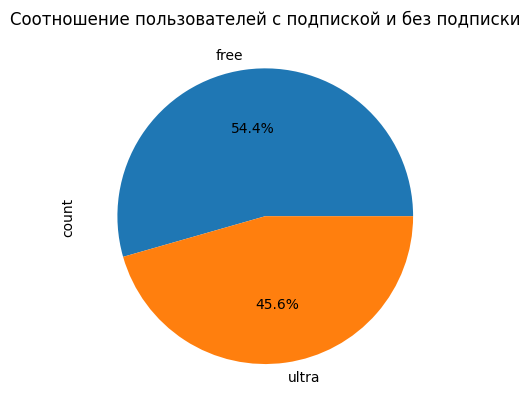

In [41]:
# подсчитаем количество пользователей с подпиской и без подписки
# построим круговую диаграмму с помощью метода plot() и параметра kind='pie'
users_go['subscription_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Соотношение пользователей с подпиской и без подписки'
)

# выведем результат на экран
plt.show()

* Количество пользователей без подписки на 8.8% больше, чем количество пользователей с подпиской. Тем не менее у компании-прокатчика есть неплохая база постоянных клиентов.

Проанализируем, как представлены разные возрастные группы пользователей. Визуализируем распределение с помощью столбчатой диаграммы:

In [42]:
# подсчитаем количество пользователей в каждой возрастной группе
users_go_age_counts = users_go['age_category'].value_counts()

# проверим результат
users_go_age_counts

age_category
от 18 до 25 лет    736
от 25 до 30 лет    498
от 30 до 35 лет    162
от 12 до 18 лет    125
от 35 до 43 лет     13
Name: count, dtype: int64

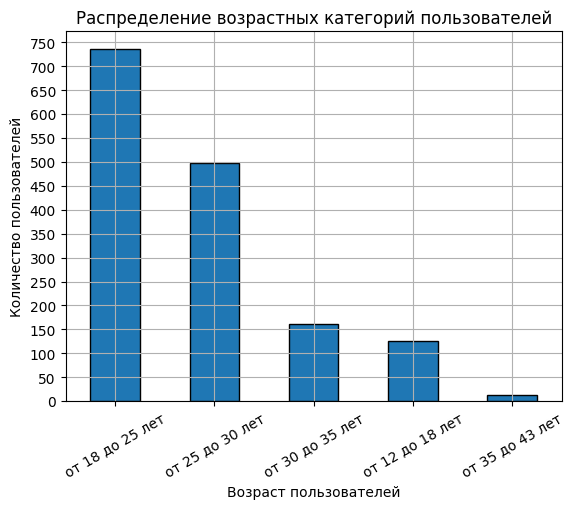

In [43]:
# построим столбчатую диаграмму с помощью метода plot() и параметра kind='bar'
users_go_age_counts.plot(kind='bar', edgecolor='black')

# обозначим название диаграммы и осей x и y
# повернём подписи
# проставим метки на оси y с шагом 50
# добавим сетку
plt.title('Распределение возрастных категорий пользователей')
plt.ylabel('Количество пользователей')
plt.xlabel('Возраст пользователей')
plt.xticks(rotation=30)
plt.yticks(range(0, 800, 50))
plt.grid(True)

# выведем на экран
plt.show()

* Самая большая категория — `от 18 до 25 лет` с **736** пользователями.
* Самая маленькая возрастная категория — `от 35 до 43 лет`. В неё входят всего лишь **13** пользователей.

Можно предположить, что электросамокаты особенно популярны у молодых людей в возрасте `от 18 до 25 лет` из-за доступности с финансовой точки зрения, удобства и экологичности. Возможно, люди в более старшем возрасте реже пользуются электросамокатом, так как чаще имеют финансовую возможность передвигаться по городу на личном автомобиле.

Ещё раз посмотрим на распределение расстояния, которое пользователь преодолел за одну поездку. Отметим медиану на графике:

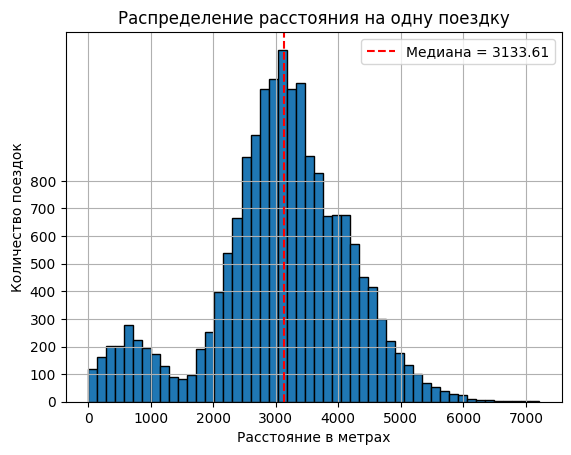

In [44]:
# рассчитаем медиану
rides_median = rides_go['distance'].median()

# построим гистограмму с количеством корзин - 50
rides_go['distance'].hist(bins=50, edgecolor='black')

# обозначим название графика 
# назовём оси x и y
# проставим метки на оси y с шагом - 100
plt.title('Распределение расстояния на одну поездку')
plt.ylabel('Количество поездок')
plt.xlabel('Расстояние в метрах')
plt.yticks(range(0, 900, 100))

# отметим медиану на графике
plt.axvline(
    rides_median,
    color='red',
    linestyle='dashed',
    label=f'Медиана = {rides_median:.2f}'
)

# отметим легенду
plt.legend()

# выведем на экран
plt.show()

* Распределение стало более равномерным и сконцентрированным, имеет форму близкую к нормальному с пиком в центре.
* Основная часть поездок занимает от **2500** до **3800** метров. Медиана **3133** метра. Поездки на расстояние более **5** км редки. Однако на гистограмме видно, что некоторая часть пользователей использует самокаты для коротких поездок - до **1500** м.

Снова проанализируем распределение продолжительности поездок:

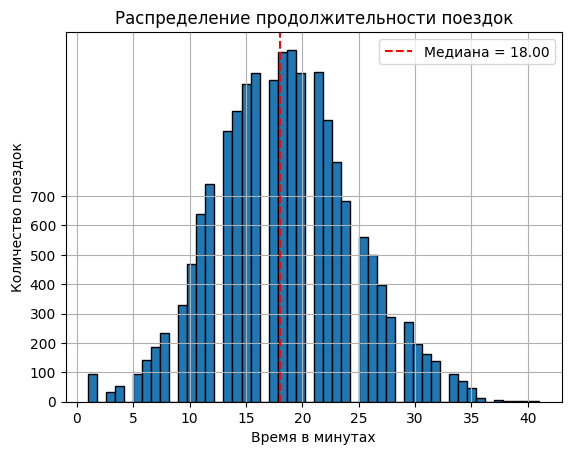

In [45]:
# рассчитаем медиану 
rides_duration_median = rides_go['duration'].median()

# построим гистограмму 
rides_go['duration'].hist(bins=50, edgecolor='black')

# обозначим название графика
# назовём оси x и y
# проставим метки на оси y с шагом - 100
plt.title('Распределение продолжительности поездок')
plt.ylabel('Количество поездок')
plt.xlabel('Время в минутах')
plt.yticks(range(0, 800, 100))

# обозначим медиану на графике
plt.axvline(
    rides_duration_median,
    color='red',
    linestyle='dashed',
    label=f'Медиана = {rides_duration_median:.2f}'
)

# обозначим легенду
plt.legend()

# выведем на экран
plt.show()

* После устранения выбросов распределение стало более концентрированным.

* Центр данных описывает медиана — **18** минут. 

**Выводы:**

* Разница в количестве пользователей в разных городах выражена слабо. Самое большое количество пользователей сервиса для аренды самокатов находится в `Пятигорске` — **219** человек. Самое маленькое количество пользователей находится в `Москве` — **168** человек.

* Количество пользователей `без подписки` на **8.8%** больше, чем количество пользователей `с подпиской`.

* Чаще всего самокат арендуют пользователи в возрасте `от 18 до 25 лет` — **736** пользователей. Самая маленькая возрастная категория — `от 35 до 43 лет`. В неё входят всего лишь **13** пользователей.

<a name="4"></a>
## Объединение данных

Объединим данные о пользователях, поездках и подписках в один датафрейм.

Предварительно проверим размеры датасетов до объединения:

In [46]:
# проверим размер датафрейма с данными о пользователях
users_go.shape

(1534, 6)

In [47]:
# проверим размер датафрейма с данными о поездках
rides_go.shape

(18068, 5)

In [48]:
# проверим размер датафрейма с данными о подписках
subscriptions_go.shape

(2, 4)

In [49]:
# используем метод merge() для объединения датафреймов users_go и good_rides_go
users_rides_go = users_go.merge(rides_go, on='user_id', how='outer')

# выведем первые 20 строк новой таблицы и проверим результат
users_rides_go.head(20)

,user_id,name,age,city,subscription_type,age_category,distance,duration,date,month_number
0,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4409.919140,26.0,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2617.592153,16.0,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,754.159807,7.0,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2694.783254,19.0,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4028.687306,27.0,2021-08-28,8
5,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2770.890808,17.0,2021-10-09,10
6,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,3039.020292,15.0,2021-10-19,10
7,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2842.118050,24.0,2021-11-06,11
8,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,3412.690668,16.0,2021-11-14,11
9,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,748.690645,16.0,2021-11-22,11


In [50]:
# объединим получившийся датафрейм с таблицей subscriptions_go
service_go = users_rides_go.merge(subscriptions_go, on='subscription_type', how='outer')

# проверим результат
service_go.head(20)

,user_id,name,age,city,subscription_type,age_category,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
0,700,Айдар,22,Омск,free,от 18 до 25 лет,2515.690719,15.0,2021-01-02,1,8,50,0
1,700,Айдар,22,Омск,free,от 18 до 25 лет,846.932642,17.0,2021-02-01,2,8,50,0
2,700,Айдар,22,Омск,free,от 18 до 25 лет,4004.434142,21.0,2021-02-04,2,8,50,0
3,700,Айдар,22,Омск,free,от 18 до 25 лет,1205.911290,10.0,2021-02-10,2,8,50,0
4,700,Айдар,22,Омск,free,от 18 до 25 лет,3047.379435,18.0,2021-02-14,2,8,50,0
5,700,Айдар,22,Омск,free,от 18 до 25 лет,4342.002254,23.0,2021-02-23,2,8,50,0
6,700,Айдар,22,Омск,free,от 18 до 25 лет,3798.334905,19.0,2021-03-03,3,8,50,0
7,700,Айдар,22,Омск,free,от 18 до 25 лет,2984.551206,16.0,2021-04-09,4,8,50,0
8,700,Айдар,22,Омск,free,от 18 до 25 лет,3360.107141,17.0,2021-06-12,6,8,50,0
9,700,Айдар,22,Омск,free,от 18 до 25 лет,2567.543847,12.0,2021-06-23,6,8,50,0


Проверим размер результирующего датафрейма `service_go`:

In [51]:
# поверим размер с помощью shape
service_go.shape

(18068, 13)

Создадим ещё 2 датафрейма из таблицы `service_go`: 

* C данными о пользователях без подписки — `free_users`
* С данными о пользователях с подпиской — `ultra_users`

In [52]:
# отфлиьтруем данные с помощью query() и сохраним результат в free_users
free_users = service_go.query('subscription_type == "free"')

# проверим результат
free_users.head()

,user_id,name,age,city,subscription_type,age_category,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
0,700,Айдар,22,Омск,free,от 18 до 25 лет,2515.690719,15.0,2021-01-02,1,8,50,0
1,700,Айдар,22,Омск,free,от 18 до 25 лет,846.932642,17.0,2021-02-01,2,8,50,0
2,700,Айдар,22,Омск,free,от 18 до 25 лет,4004.434142,21.0,2021-02-04,2,8,50,0
3,700,Айдар,22,Омск,free,от 18 до 25 лет,1205.911290,10.0,2021-02-10,2,8,50,0
4,700,Айдар,22,Омск,free,от 18 до 25 лет,3047.379435,18.0,2021-02-14,2,8,50,0


In [53]:
# отфлиьтруем данные с помощью query() и сохраним результат в ultra_users
ultra_users = service_go.query('subscription_type == "ultra"')

# проверим результат
ultra_users.head()

,user_id,name,age,city,subscription_type,age_category,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
11568,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4409.919140,26.0,2021-01-01,1,6,0,199
11569,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2617.592153,16.0,2021-01-18,1,6,0,199
11570,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,754.159807,7.0,2021-04-20,4,6,0,199
11571,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2694.783254,19.0,2021-08-11,8,6,0,199
11572,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4028.687306,27.0,2021-08-28,8,6,0,199


Ознакомимся с размером двух новых датафреймов:

In [54]:
# проверим размер датафрейма free_users
free_users.shape

(11568, 13)

In [55]:
# проверим размер датафрейма ultra_users
ultra_users.shape

(6500, 13)

Визуализируем информацию о **расстоянии поездок** для пользователей без подписки и с подпиской:

Text(0, 0.5, 'Количество поездок')

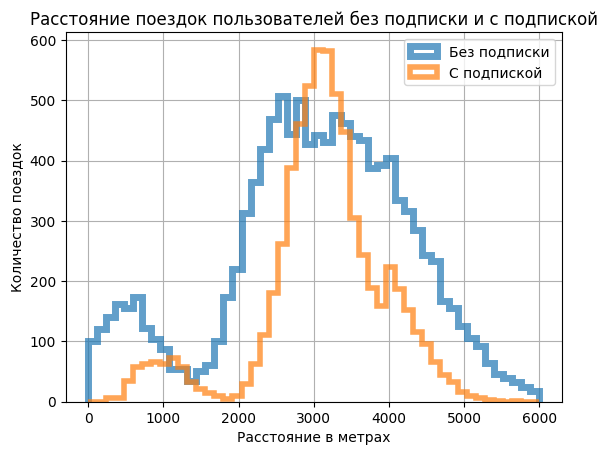

In [56]:
# построим гистограмму на основе данных таблицы free_users
ax = free_users.plot(
    kind='hist',
    y='distance',
    histtype='step',
    range=(0, 6000),
    bins=50,
    linewidth=5,
    alpha=0.7,
    label='Без подписки',
)

# наложим на гистограмму по таблице ultra_users
ultra_users.plot(
    kind='hist',
    y='distance',
    histtype='step',
    range=(0, 6000),
    bins=50,
    linewidth=4,
    alpha=0.7,
    label='С подпиской',
    ax=ax,
    grid=True,
    legend=True,
)

# дадим название графику и осям
ax.set_title('Расстояние поездок пользователей без подписки и с подпиской')
ax.set_xlabel('Расстояние в метрах')
ax.set_ylabel('Количество поездок')

* Оба распределения имеют форму, близкую к нормальному.
* Пользователи без подписки чаще совершают поездки на более длинные расстояния по сравнению с пользователями с подпиской.
* Распределение поездок без подписки шире, что указывает на большую вариативность значений. Эти пользователи чаще проезжают расстояния от **2200** до **3500** метров.
* В свою очередь, распределение поездок с подпиской более узкое и концентрированное: пользователи в основном передвигаются на расстояния от **3000** до **3200** метров.

Визуализируем информацию о **времени поездок** для пользователей без подписки и с подпиской:

Text(0, 0.5, 'Количество поездок')

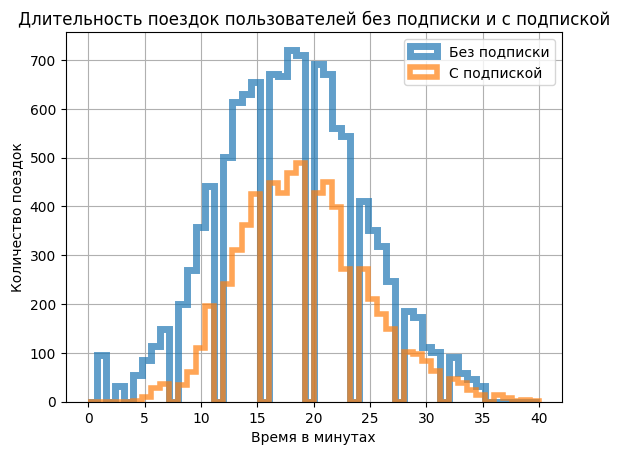

In [57]:
# построим гистограмму на основе данных таблицы free_users
ax_2 = free_users.plot(
    kind='hist',
    y='duration',
    histtype='step',
    range=(0, 40),
    bins=50,
    linewidth=5,
    alpha=0.7,
    label='Без подписки',
)

# наложим на гистограмму по таблице ultra_users
ultra_users.plot(
    kind='hist',
    y='duration',
    histtype='step',
    range=(0, 40),
    bins=50,
    linewidth=4,
    alpha=0.7,
    label='С подпиской',
    ax=ax_2,
    grid=True,
    legend=True,
)

# дадим название графику и осям
ax_2.set_title('Длительность поездок пользователей без подписки и с подпиской')
ax_2.set_xlabel('Время в минутах')
ax_2.set_ylabel('Количество поездок')

* Оба распределения имеют форму нормального распределения.
* По длительности поездки пользователей без подписки и с подпиской практически не отличаются: чаще всего они длятся от **16** до **19** минут.

**Вывод:**

* Мы объединили 3 датафрейма с информацией о пользователях, поездках и типе подписки в один датафрейм — `service_go`.
* Создали ещё 2 датафрейма из таблицы service_go: с данными о пользователях без подписки и с подпиской.
* Визуализировали информацию о расстоянии и длительности поездок для пользователей без подписки и с подпиской с помощью гистограммы.

<a name="5"></a>
## Подсчёт выручки

Создадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными — `service_go`.

Найдём для каждого пользователя за каждый месяц:

* Cуммарное расстояние;
* Количество поездок;
* Суммарное время.

Создадим датафрейм `aggregated_data`:

In [58]:
# создадим копию датафрейма service_go
aggregated_data = service_go.copy()

Подсчитаем **суммарное расстояние** для каждого пользователя за каждый месяц:

In [59]:
# c помощью сводной таблицы подсчитаем суммарное расстояние для каждого пользователя за каждый месяц
total_distance = service_go.pivot_table(
    index=['user_id', 'month_number'],
    values='distance',
    aggfunc='sum'
).reset_index().rename(columns={'distance':'distance_monthly'})

# проверим результат
total_distance.head(20)

,user_id,month_number,distance_monthly
0,1,1,7027.511294
1,1,4,754.159807
2,1,8,6723.470560
3,1,10,5809.911100
4,1,11,7003.499363
5,1,12,6751.629942
6,2,3,10187.723006
7,2,4,6164.381824
8,2,6,3255.338202
9,2,7,6780.722964


Подсчитаем **суммарное количество** поездок для каждого пользователя за каждый месяц:

In [60]:
# c помощью сводной таблицы подсчитаем суммарное количество поездок в месяц для каждого пользователя 
total_rides = service_go.pivot_table(
    index=['user_id', 'month_number'],
    values='name',
    aggfunc='count',
).reset_index().rename(columns={'name':'rides_monthly'})

# проверим результат
total_rides.head(20)

,user_id,month_number,rides_monthly
0,1,1,2
1,1,4,1
2,1,8,2
3,1,10,2
4,1,11,3
5,1,12,2
6,2,3,3
7,2,4,2
8,2,6,1
9,2,7,2


Подсчитаем **суммарное время** поездок для каждого пользователя за каждый месяц:

In [61]:
# c помощью сводной таблицы подсчитаем суммарное время поездок в месяц для каждого пользователя
total_duration = service_go.pivot_table(
    index=['user_id','month_number'],
    values='duration',
    aggfunc='sum',
).reset_index().rename(columns={'duration':'duration_monthly'})

# проверим результат
total_duration.head(10)

,user_id,month_number,duration_monthly
0,1,1,42.0
1,1,4,7.0
2,1,8,46.0
3,1,10,32.0
4,1,11,56.0
5,1,12,28.0
6,2,3,63.0
7,2,4,40.0
8,2,6,14.0
9,2,7,48.0


Запишем полученные данные в новый датафрейм `aggregated_data`:

In [62]:
# запишем информацию в новый столбец датафрейма aggregated_data - 'duration_monthly'
aggregated_data = aggregated_data.merge(
    total_distance,
    on=['user_id', 'month_number'],
    how='outer'
).merge(
    total_rides,
    on=['user_id', 'month_number'],
    how='outer'
).merge(
    total_duration,
    on=['user_id', 'month_number'],
    how='outer'
)

# проверим результат
aggregated_data.head(20)

,user_id,name,age,city,subscription_type,age_category,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee,distance_monthly,rides_monthly,duration_monthly
0,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4409.919140,26.0,2021-01-01,1,6,0,199,7027.511294,2,42.0
1,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2617.592153,16.0,2021-01-18,1,6,0,199,7027.511294,2,42.0
2,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,754.159807,7.0,2021-04-20,4,6,0,199,754.159807,1,7.0
3,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2694.783254,19.0,2021-08-11,8,6,0,199,6723.470560,2,46.0
4,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4028.687306,27.0,2021-08-28,8,6,0,199,6723.470560,2,46.0
5,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2770.890808,17.0,2021-10-09,10,6,0,199,5809.911100,2,32.0
6,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,3039.020292,15.0,2021-10-19,10,6,0,199,5809.911100,2,32.0
7,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2842.118050,24.0,2021-11-06,11,6,0,199,7003.499363,3,56.0
8,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,3412.690668,16.0,2021-11-14,11,6,0,199,7003.499363,3,56.0
9,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,748.690645,16.0,2021-11-22,11,6,0,199,7003.499363,3,56.0


В этот же датафрейм добавим **столбец с помесячной выручкой**, которую принес каждый пользователь. 

In [63]:
# рассчитаем выручку от каждого пользователя за каждый месяц
aggregated_data['income_monthly'] = (aggregated_data['duration_monthly'] * aggregated_data['minute_price']) + (aggregated_data['start_ride_price'] * aggregated_data['rides_monthly']) + aggregated_data['subscription_fee']

# проверим результат
aggregated_data.head() 

,user_id,name,age,city,subscription_type,age_category,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee,distance_monthly,rides_monthly,duration_monthly,income_monthly
0,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4409.919140,26.0,2021-01-01,1,6,0,199,7027.511294,2,42.0,451.0
1,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2617.592153,16.0,2021-01-18,1,6,0,199,7027.511294,2,42.0,451.0
2,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,754.159807,7.0,2021-04-20,4,6,0,199,754.159807,1,7.0,241.0
3,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2694.783254,19.0,2021-08-11,8,6,0,199,6723.470560,2,46.0,475.0
4,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4028.687306,27.0,2021-08-28,8,6,0,199,6723.470560,2,46.0,475.0


В итоговой выборке можно заметить строки-дубликаты. Удалим такие строки:

In [64]:
# удалим строки-дубликаты по ключевым столбцам 'user_id' и 'month_number'
aggregated_data = aggregated_data.drop_duplicates(subset=['user_id', 'month_number'])

# проверим результат
aggregated_data.head(10)

,user_id,name,age,city,subscription_type,age_category,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee,distance_monthly,rides_monthly,duration_monthly,income_monthly
0,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4409.919140,26.0,2021-01-01,1,6,0,199,7027.511294,2,42.0,451.0
2,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,754.159807,7.0,2021-04-20,4,6,0,199,754.159807,1,7.0,241.0
3,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2694.783254,19.0,2021-08-11,8,6,0,199,6723.470560,2,46.0,475.0
5,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2770.890808,17.0,2021-10-09,10,6,0,199,5809.911100,2,32.0,391.0
7,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,2842.118050,24.0,2021-11-06,11,6,0,199,7003.499363,3,56.0,535.0
10,1,Кира,22,Тюмень,ultra,от 18 до 25 лет,4031.020195,18.0,2021-12-14,12,6,0,199,6751.629942,2,28.0,367.0
12,2,Станислав,31,Омск,ultra,от 30 до 35 лет,3105.086678,25.0,2021-03-15,3,6,0,199,10187.723006,3,63.0,577.0
15,2,Станислав,31,Омск,ultra,от 30 до 35 лет,2805.786329,21.0,2021-04-08,4,6,0,199,6164.381824,2,40.0,439.0
17,2,Станислав,31,Омск,ultra,от 30 до 35 лет,3255.338202,14.0,2021-06-20,6,6,0,199,3255.338202,1,14.0,283.0
18,2,Станислав,31,Омск,ultra,от 30 до 35 лет,3942.817648,21.0,2021-07-02,7,6,0,199,6780.722964,2,48.0,487.0


<a name="6"></a>
## Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции. 

Проверим гипотезы для развития бизнеса:

* Пользователи с подпиской тратят больше времени на поездки;

* Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130;

* Выручка от пользователей с подпиской по месяцам будет выше, чем выручка от пользователей без подписки;

Предположим, с помощью какого теста можно проверить следующую гипотезу:

* Kоличество обращений в техподдержку значительно снизилось после обновления серверов, с которыми взаимодействует мобильное приложение.

<a name="6.1"></a>
### Гипотеза: пользователи с подпиской тратят больше времени на поездки

Сформулируем нулевую и альтернативную правостороннюю гипотезы:

* Нулевая гипотеза: среднее время поездок пользователей из двух групп одинаково;
* Альтернативная гипотеза: среднее время поездок у пользователей с подпиской больше, чем у пользователей без подписки.

Проверим гипотезу с помощью t-теста:

In [65]:
# зададим уровень значимости - 5%
alpha = 0.05

# время поездок первой группы пользователей - с подпиской
first_group_users = ultra_users['duration']

# время поездок второй группы пользователей - без подписки
second_group_users = free_users['duration']

# проведём t-тест для двух выборок
# в качестве альтернативной гипотезы используем одностороннюю гипотезу "больше"
results = st.ttest_ind(first_group_users, second_group_users, alternative='greater')

# выведем p-value, округлив его для большей читаемости
print(f'p-value:{results.pvalue:.10f}')

# проверим p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value:0.0000000000
Отвергаем нулевую гипотезу


**Вывод**:

* Значение p-value (**0.0000000000**) меньше уровня статистической значимости (**0.05**), поэтому нулевую гипотезу отвергаем в пользу альтернативной. Это указывает на то, что пользователи с подпиской действительно могут использовать самокат дольше, чем пользователи без подписки.

<a name="6.2"></a>
### Гипотеза: среднее расстояние за одну поездку у пользователей с подпиской не превышает 3130

Сформулируем нулевую и альтернативную правостороннюю гипотезу:

* Нулевая гипотеза: среднее расстояние за одну поездку у пользователей с подпиской равно 3130 метрам;

* Альтернативная гипотеза: среднее расстояние за одну поездку у пользователей с подпиской больше 3130 метров.

Проверим гипотезу с помощью t-теста:

In [66]:
# укажем интересующее значение
interested_value = 3130

# обозначим уровень статистической значимости
alpha_2 = 0.05

# используем метод st.ttest_1samp
results_2 = st.ttest_1samp(
    ultra_users['distance'],
    interested_value,
    alternative='greater')

# добавим в аргумент p-value
print('р-значение:', results_2.pvalue)

# сравним полученный p-value и уровень значимости
if (results_2.pvalue < alpha_2):
    print('Отвергаем нулевую гипотезу: среднее расстояние значимо превышает 3130 метров')
else:
    print('Не получилось отвергнуть нулевую гипотезу: среднее расстояние близко к показателю 3130 метров')

р-значение: 0.9195368847849785
Не получилось отвергнуть нулевую гипотезу: среднее расстояние близко к показателю 3130 метров


**Вывод**

* Не удалось отвергнуть нулевую гипотезу. Данные не подтверждают, что среднее расстояние за одну поездку у пользователей с подпиской больше 3130 метров.

<a name="6.3"></a>
### Гипотеза: выручка от пользователей с подпиской по месяцам будет выше, чем выручка от пользователей без подписки

Сформулируем нулевую и альтернативную правостороннюю гипотезы:

* Нулевая гипотеза: выручка по месяцам от пользователей из двух групп будет одинакова;
* Альтернативная гипотеза: выручка по месяцам от пользователей с подпиской будет выше, чем выручка от пользователей без подписки.

Проверим гипотезу с помощью t-теста:

In [67]:
# зададим уровень значимости - 5%
alpha_3 = 0.05

# агрегируем данные, чтобы получить помесячную выручку первой группы пользователей - с подпиской 
income_first_group = (
    aggregated_data.query('subscription_type == "ultra"')['income_monthly'])

# помесячная выручка второй группы пользователей - без подписки
income_second_group = (
    aggregated_data.query('subscription_type == "free"')['income_monthly'])

# проведём t-тест для двух выборок
# в качестве альтернативной гипотезы используем одностороннюю гипотезу - "больше"
results_3 = st.ttest_ind(
    income_first_group,
    income_second_group,
    alternative='greater')

# выведем p-value и округлим его до большей читаемости
print(f'p-value:{results_3.pvalue:}')

# проверим p-value
if results_3.pvalue < alpha_3:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергать нулевую гипотезу')

p-value:1.8850394384715216e-31
Отвергаем нулевую гипотезу


**Выводы**:

* Отвергаем нулевую гипотезу в пользу альтернативной. Вероятно, подписка действительно приносит бизнесу больший доход.

<a name="6.4"></a>
### Гипотеза: количество обращений в техподдержку значительно снизилось после обновления серверов

Предположим, что техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Команда надеется, что из-за этого количество обращений в техподдержку значимо снизилось. 

Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него.

В таком случае, нулевую и альтернативную гипотезы следует сформулировать таким образом:

* Нулевая гипотеза: количество обращений в техподдержку до обновления и после обновления одинаково;
* Альтернативная гипотеза: количество обращений в техподдержку после обновления меньше, чем количество до обновления.

Для проверки этой гипотезы о равенстве среднего генеральной совокупности для зависимых выборок нам понадобился бы тест `scipy.stats.ttest_rel()`.

<a name="7"></a>
## Общий вывод

В ходе исследовательского анализа данных мы:

* Описали и визуализировали общую информацию о пользователях и поездках: пользователей в разных городах почти одинаково, больше всего — в Пятигорске (**219**), меньше всего — в Москве (**168**). Пользователей без подписки на **8,8%** больше, чем с подпиской. Чаще всего самокаты арендуют молодые люди 18-25 лет (**736** пользователей), а категория 35-43 лет — самая малочисленная (**13** пользователей).


* Объединили 3 датафрейма в service_go. Создали два датафрейма с пользователями по типу подписки. Визуализировали расстояние и длительность поездок на гистограммах.


* Подсчитали выручку: нашли для каждого пользователя суммарное расстояние, количество поездок и суммарное время поездок за каждый месяц.

Мы проверили 3 гипотезы, а также предположили возможный способ проверки одной гипотезы:

* Пользователи с подпиской тратят больше времени на поездки.

Отвергнули нулевую гипотезу в пользу альтернативной. Вероятно, пользователи с подпиской используют самокат дольше, чем пользователи без подписки.

* Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130.

Не удалось отвергнуть нулевую гипотезу. Данные не подтверждают, что среднее расстояние за одну поездку у пользователей с подпиской больше **3130** метров.

* Помесячная выручка от пользователей с подпиской по месяцам будет выше, чем выручка от пользователей без подписки.

Отвергнули нулевую гипотезу в пользу альтернативной. Вероятно, подписка действительно приносит бизнесу больший доход.

* Kоличество обращений в техподдержку значительно снизилось после обновления серверов, с которыми взаимодействует мобильное приложение.

Для проверки этой гипотезы о равенстве среднего генеральной совокупности для зависимых выборок нам понадобился бы тест `scipy.stats.ttest_rel()`.

В разрезе исследования можно предложить следующие **рекомендации по развитию аренды самокатов**:

* Ввиду того, что пользователи с подпиской приносят больше дохода, можно усилить или разработать новые стратегии маркетинга подписки на сервис.
* Возможно, следует предложить более выгодные тарифы пользователям Москвы, чтобы повысить активность в этом городе.
* Так как категория пользователей в возрасте от 35 до 43 лет - самая малочисленная, стоит дополнительно исследовать вопрос о том, как увеличить активность таких пользователей. Например, с помощью опросов.